## Assignment 11

### Imports

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.model_selection import train_test_split

# Add these before importing torch
os.environ['MIOPEN_LOG_LEVEL'] = '1'  # Enable logging
os.environ['MIOPEN_DEBUG_DISABLE_FIND_DB'] = '1'
os.environ['MIOPEN_DEBUG_CONV_IMPLICIT_GEMM'] = '0'
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

# For easy copying
"""../../MainProject/Assignment11/data/kinect_good_preprocessed_not_cut_start_stop"""

'../../MainProject/Assignment11/data/kinect_good_preprocessed_not_cut_start_stop'

### Step 1: Split CSV Files

In [2]:
def split_csv_files(datafolder: str, train_size: float = 0.8, val_size: float = 0.1, test_size: float = 0.1, random_seed: int = 42):
    """Split CSV files into train/val/test sets"""
    csv_files = [f for f in os.listdir(datafolder) if f.endswith('.csv')]
    
    train_val, test = train_test_split(
        csv_files,
        test_size=test_size,
        random_state=random_seed
    )
    
    train, val = train_test_split(
        train_val,
        train_size=train_size/(train_size+val_size),
        random_state=random_seed
    )
    
    print(f"Train: {len(train)} files, Val: {len(val)} files, Test: {len(test)} files")
    return train, val, test


def flip_nodes(X:pd.DataFrame, flip_x: bool = True, flip_y: bool = True, flip_z: bool = True) -> pd.DataFrame:
    '''
    Flips the node coordinates of the input kinect DataFrame.

    OBS: FrameNo column must be removed beforehand.

    Args:
        X: Input DataFrame
        flip_x: If the x-coordinate should be flipped
        flip_y: If the y-coordinate should be flipped
        flip_z: If the z-coordinate should be flipped

    Returns:
        Copy of the original DataFrame with flipped coordinates
    '''
    mirror_pairs = [
        (1, 3),   # shoulders
        (2, 4),   # elbows
        (5, 6),   # hands
        (7, 8),   # hips
        (9, 10),  # knees
        (11, 12), # feet
    ]

    df = X.copy()

    for left, right in mirror_pairs:
        x_idx_left, y_idx_left, z_idx_left = left * 3, left * 3 + 1, left * 3 + 2
        x_idx_right, y_idx_right, z_idx_right = right * 3, right * 3 + 1, right * 3 + 2

        # Swap left with right and vice verse
        if flip_x:
            df[df.columns[x_idx_left]], df[df.columns[x_idx_right]] = \
                df[df.columns[x_idx_right]], df[df.columns[x_idx_left]]
        if flip_x:
            df[df.columns[y_idx_left]], df[df.columns[y_idx_right]] = \
                df[df.columns[y_idx_right]], df[df.columns[y_idx_left]]
        if flip_x:
            df[df.columns[z_idx_left]], df[df.columns[z_idx_right]] = \
                df[df.columns[z_idx_right]], df[df.columns[z_idx_left]]
    
    return df

### Step 2: Create Time Series Dataset Class for LSTM

In [3]:
class BinarySeriesDataset(Dataset):
    """Custom Dataset for LSTM time series prediction"""
    
    def __init__(self, file_list, data_folder, sequence_length=10, label_column='label', mirror=False):
        """
        Args:
            file_list: List of CSV file names
            data_folder: Path to folder containing CSV files
            sequence_length: Number of time steps to use as input (lookback window)
            target_column: Name of the column to predict
        """
        self.sequences = []
        self.targets = []
        
        for file_name in file_list:
            # Load CSV
            file_path = os.path.join(data_folder, file_name)
            df = pd.read_csv(file_path)
            
            # Assume last column is target, or specify target_column
            if label_column not in df.columns:
                # Use last column as target if specified column not found
                target_col = df.columns[-1]
            else:
                target_col = label_column

            # Remove first column 'FrameNo'
            if 'FrameNo' in df.columns:
                df.drop('FrameNo', axis=1, inplace=True)

            # Create mirrired data
            if mirror:
                df = flip_nodes(df)
            
            # Separate features and label
            feature_cols = [col for col in df.columns if col != target_col]
            features = df[feature_cols].values
            target = df[target_col].values

            # Scale the data
            scaler = StandardScaler()
            scaler.fit(features)
            features = scaler.transform(features)
            
            # Create sequences
            for i in range(len(features) - sequence_length):
                seq_features = features[i:i+sequence_length]
                seq_target = target[i+sequence_length]  # Predict next value
                
                self.sequences.append(seq_features)
                self.targets.append(seq_target)
        
        # Convert to numpy arrays
        self.sequences = np.array(self.sequences, dtype=np.float32)
        self.targets = np.array(self.targets, dtype=np.float32)
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return torch.tensor(self.sequences[idx]), torch.tensor(self.targets[idx])
    
    def get_sequences(self):
        return self.sequences
    
    def get_targets(self):
        return self.targets
    
    def concat(self, dataset: Dataset):
        np.append(self.sequences, dataset.get_sequences())

### Step 3: Create Data Loaders

In [4]:
def create_lstm_loaders(data_folder: str, 
                       train_files: list,
                       val_files: list, 
                       test_files: list,
                       sequence_length: int = 10,
                       batch_size: int = 32,
                       target_column: str = 'target',
                       mirror: bool = False):
    """
    Create PyTorch DataLoaders for LSTM training
    
    Returns:
        train_loader, val_loader, test_loader, input_dim
    """
    # Create datasets
    train_dataset = BinarySeriesDataset(train_files, data_folder, sequence_length, target_column)

    if mirror:
        mirrored_dataset = BinarySeriesDataset(train_files, data_folder, sequence_length, target_column, mirror=True)
        train_dataset.concat(mirrored_dataset)

    val_dataset = BinarySeriesDataset(val_files, data_folder, sequence_length, target_column)
    test_dataset = BinarySeriesDataset(test_files, data_folder, sequence_length, target_column)
    
    # Get input dimension from first sample
    sample_seq, _ = train_dataset[0]
    input_dim = sample_seq.shape[1]  # Number of features
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
    
    print(f"\n📊 Dataset Statistics:")
    print(f"   Train samples: {len(train_dataset)}")
    print(f"   Val samples: {len(val_dataset)}")
    print(f"   Test samples: {len(test_dataset)}")
    print(f"   Input dimension: {input_dim}")
    print(f"   Sequence length: {sequence_length}")
    
    return train_loader, val_loader, test_loader, input_dim

### Step 4: Define LSTM Model

In [5]:
class LSTMBinaryClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, output_dim=1, dropout=0.2):
        super(LSTMBinaryClassifier, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        # Initialize hidden state and cell state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Take the last time step's output
        out = out[:, -1, :]
        
        # Dropout and fully connected layer
        out = self.dropout(out)
        out = self.fc(out)
        
        return out

### Step 5: Training Function

In [6]:
def train_binary_classifier(train_loader, val_loader, input_dim, 
                            epochs=50, learning_rate=0.001, device='cpu',
                            save_plots=True, plot_dir='./../plots'):
    """Train LSTM for binary classification"""
    
    model = LSTMBinaryClassifier(input_dim=input_dim).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    best_val_accuracy = 0
    best_model_state = None
    
    if save_plots:
        os.makedirs(plot_dir, exist_ok=True)
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for sequences, labels in train_loader:
            sequences, labels = sequences.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(sequences)
            
            # Binary classification loss
            loss = criterion(outputs.squeeze(), labels)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item()
            
            # Calculate accuracy
            predictions = (torch.sigmoid(outputs) > 0.5).float()
            train_correct += (predictions.squeeze() == labels).sum().item()
            train_total += labels.size(0)
        
        avg_train_loss = train_loss / len(train_loader)
        train_accuracy = train_correct / train_total
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)
        
        # Validation phase
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for sequences, labels in val_loader:
                sequences, labels = sequences.to(device), labels.to(device)
                outputs = model(sequences)
                loss = criterion(outputs.squeeze(), labels)
                val_loss += loss.item()
                
                # Calculate accuracy
                predictions = (torch.sigmoid(outputs) > 0.5).float()
                val_correct += (predictions.squeeze() == labels).sum().item()
                val_total += labels.size(0)
        
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = val_correct / val_total
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)
        
        # Save best model
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model_state = model.state_dict().copy()
        
        # Learning rate scheduling
        scheduler.step(avg_val_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}]')
            print(f'  Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}', end=' ')
            print(f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    # Plot training history
    if save_plots:
        print("\n📈 Plotting training history...")
        save_path = os.path.join(plot_dir, 'training_history.png')
        training_history = [train_losses, val_losses, train_accuracies, val_accuracies, save_path]
    
    return model, train_losses, val_losses, train_accuracies, val_accuracies, training_history

### Step 6: Evaluation

In [7]:
def plot_confusion_matrix(conf_matrix, save_path=None):
    """
    Plot confusion matrix as a heatmap.
    
    Args:
        conf_matrix: Confusion matrix from sklearn
        save_path: Optional path to save the figure
    """
    plt.figure(figsize=(8, 6))
    
    # Create heatmap
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'],
                cbar_kws={'label': 'Count'})
    
    plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    
    # Add text annotations with percentages
    total = np.sum(conf_matrix)
    for i in range(2):
        for j in range(2):
            percentage = conf_matrix[i, j] / total * 100
            plt.text(j+0.5, i+0.7, f'({percentage:.1f}%)', 
                    ha='center', va='center', color='gray', fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Confusion matrix saved to {save_path}")
    
    plt.show()


def plot_roc_curve(y_true, y_prob, save_path=None):
    """
    Plot ROC curve with AUC score.
    
    Args:
        y_true: True labels (0 or 1)
        y_prob: Predicted probabilities for class 1
        save_path: Optional path to save the figure
    """
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    
    # Calculate Youden's J statistic for optimal threshold
    youden_j = tpr - fpr
    optimal_idx = np.argmax(youden_j)
    optimal_threshold = thresholds[optimal_idx]
    
    plt.figure(figsize=(8, 6))
    
    # Plot ROC curve
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    
    # Plot diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
             label='Random Classifier (AUC = 0.5)')
    
    # Mark optimal threshold
    plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100, 
               zorder=5, label=f'Optimal Threshold\n(Youden\'s J = {youden_j[optimal_idx]:.3f})')
    
    # Add threshold annotation
    plt.annotate(f'Threshold = {optimal_threshold:.3f}', 
                xy=(fpr[optimal_idx], tpr[optimal_idx]),
                xytext=(fpr[optimal_idx] + 0.15, tpr[optimal_idx] - 0.1),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # Fill area under curve
    plt.fill_between(fpr, tpr, alpha=0.3, color='orange')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    plt.title('ROC Curve', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Add text box with additional info
    textstr = f'AUC = {roc_auc:.3f}\nOptimal Threshold = {optimal_threshold:.3f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
            verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ ROC curve saved to {save_path}")
    
    plt.show()
    
    return roc_auc, optimal_threshold


def plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies, save_path=None):
    """
    Plot training history (loss and accuracy curves).
    
    Args:
        train_losses: List of training losses per epoch
        val_losses: List of validation losses per epoch
        train_accuracies: List of training accuracies per epoch
        val_accuracies: List of validation accuracies per epoch
        save_path: Optional path to save the figure
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot losses
    epochs = range(1, len(train_losses) + 1)
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Highlight minimum validation loss
    min_val_loss_idx = np.argmin(val_losses)
    ax1.scatter(min_val_loss_idx + 1, val_losses[min_val_loss_idx], 
               color='green', s=100, zorder=5, 
               label=f'Best Model (Epoch {min_val_loss_idx + 1})')
    ax1.legend()
    
    # Plot accuracies
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy', linewidth=2)
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Highlight best validation accuracy
    max_val_acc_idx = np.argmax(val_accuracies)
    ax2.scatter(max_val_acc_idx + 1, val_accuracies[max_val_acc_idx], 
               color='green', s=100, zorder=5,
               label=f'Best Accuracy: {val_accuracies[max_val_acc_idx]:.3f}')
    ax2.legend()
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Training history saved to {save_path}")
    
    plt.show()


def evaluate_binary_classifier(model, test_loader, device='cpu', 
                               save_plots=True, plot_dir='./../plots'):
    """
    Evaluate binary classifier with multiple metrics and visualizations.
    
    Args:
        model: Trained PyTorch model
        test_loader: DataLoader for test set
        device: 'cuda' or 'cpu'
        save_plots: Whether to save plots to disk
        plot_dir: Directory to save plots
    """
    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    # Create plot directory if saving
    if save_plots:
        os.makedirs(plot_dir, exist_ok=True)
    
    with torch.no_grad():
        for sequences, labels in test_loader:
            sequences = sequences.to(device)
            outputs = model(sequences)
            
            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities > 0.5).float()
            
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    # Convert to numpy arrays
    all_predictions = np.array(all_predictions).flatten()
    all_labels = np.array(all_labels).flatten()
    all_probabilities = np.array(all_probabilities).flatten()
    
    # Calculate metrics
    conf_matrix = confusion_matrix(all_labels, all_predictions)
    tn, fp, fn, tp = conf_matrix.ravel()
    
    metrics = {
        'accuracy': accuracy_score(all_labels, all_predictions),
        'precision': precision_score(all_labels, all_predictions, zero_division=0),
        'recall': recall_score(all_labels, all_predictions, zero_division=0),
        'f1_score': f1_score(all_labels, all_predictions, zero_division=0),
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'roc_auc': roc_auc_score(all_labels, all_probabilities),
        'confusion_matrix': conf_matrix,
        'predictions': all_predictions,
        'probabilities': all_probabilities,
        'true_labels': all_labels
    }
    
    # Add additional derived metrics
    metrics['balanced_accuracy'] = (metrics['recall'] + metrics['specificity']) / 2
    metrics['false_positive_rate'] = fp / (fp + tn) if (fp + tn) > 0 else 0
    metrics['false_negative_rate'] = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    # Print results
    print("\n" + "="*50)
    print("📊 BINARY CLASSIFICATION RESULTS")
    print("="*50)
    print(f"  Accuracy:           {metrics['accuracy']:.4f}")
    print(f"  Balanced Accuracy:  {metrics['balanced_accuracy']:.4f}")
    print(f"  Precision:          {metrics['precision']:.4f}")
    print(f"  Recall (Sensitivity): {metrics['recall']:.4f}")
    print(f"  Specificity:        {metrics['specificity']:.4f}")
    print(f"  F1-Score:           {metrics['f1_score']:.4f}")
    print(f"  ROC-AUC:            {metrics['roc_auc']:.4f}")
    print(f"\n  False Positive Rate: {metrics['false_positive_rate']:.4f}")
    print(f"  False Negative Rate: {metrics['false_negative_rate']:.4f}")
    
    print(f"\nConfusion Matrix:")
    print(f"  True Negatives:  {tn:>6}  |  False Positives: {fp:>6}")
    print(f"  False Negatives: {fn:>6}  |  True Positives:  {tp:>6}")
    
    # Plot confusion matrix
    print("\n" + "-"*50)
    print("📈 Generating Confusion Matrix Plot...")
    if save_plots:
        save_path = os.path.join(plot_dir, 'confusion_matrix.png')
    else:
        save_path = None
    plot_confusion_matrix(conf_matrix, save_path=save_path)
    
    # Plot ROC curve
    print("📈 Generating ROC Curve Plot...")
    if save_plots:
        save_path = os.path.join(plot_dir, 'roc_curve.png')
    else:
        save_path = None
    roc_auc, optimal_threshold = plot_roc_curve(all_labels, all_probabilities, save_path=save_path)
    
    print("\n" + "="*50)
    print(f"✨ Optimal classification threshold: {optimal_threshold:.3f}")
    print(f"   (Based on Youden's J statistic)")
    print("="*50)
    
    return metrics

### Step 7: Excecution

Train: 143 files, Val: 18 files, Test: 18 files

📊 Dataset Statistics:
   Train samples: 28980
   Val samples: 3634
   Test samples: 3378
   Input dimension: 39
   Sequence length: 10
Epoch [10/50]
  Train Loss: 0.0438, Train Acc: 0.9825 Val Loss: 0.4965, Val Acc: 0.9074
Epoch [20/50]
  Train Loss: 0.0237, Train Acc: 0.9921 Val Loss: 0.7264, Val Acc: 0.9104
Epoch [30/50]
  Train Loss: 0.0100, Train Acc: 0.9966 Val Loss: 1.0340, Val Acc: 0.9024
Epoch [40/50]
  Train Loss: 0.0059, Train Acc: 0.9978 Val Loss: 1.1384, Val Acc: 0.9015
Epoch [50/50]
  Train Loss: 0.0049, Train Acc: 0.9979 Val Loss: 1.1913, Val Acc: 0.9013

📈 Plotting training history...
✅ Training history saved to ./../plots\training_history.png


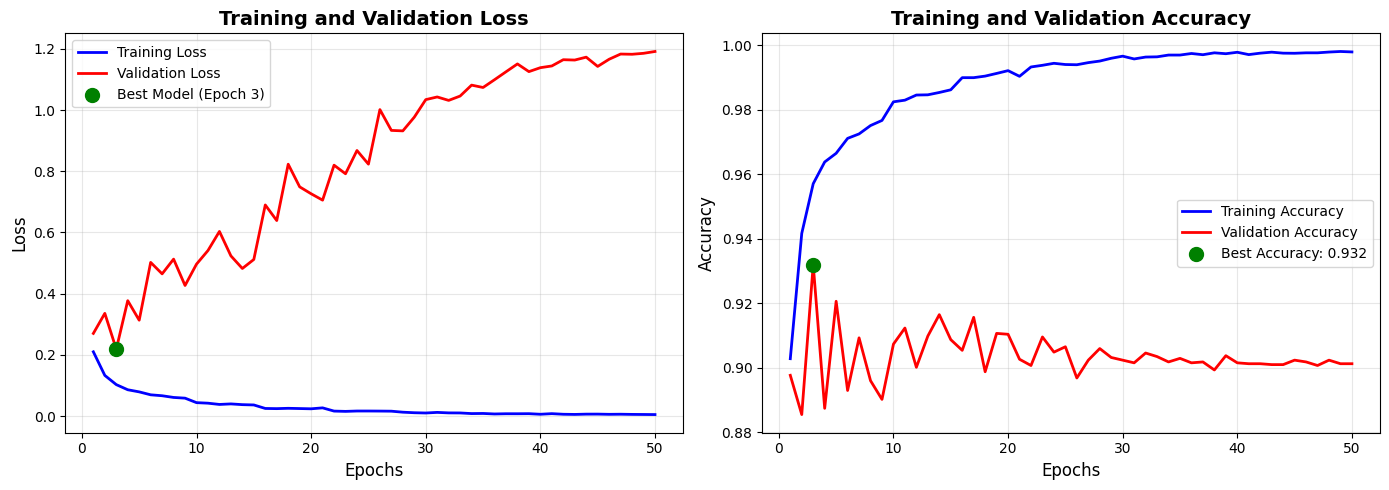


📊 BINARY CLASSIFICATION RESULTS
  Accuracy:           0.9173
  Balanced Accuracy:  0.9170
  Precision:          0.9608
  Recall (Sensitivity): 0.9177
  Specificity:        0.9162
  F1-Score:           0.9388
  ROC-AUC:            0.9752

  False Positive Rate: 0.0838
  False Negative Rate: 0.0823

Confusion Matrix:
  True Negatives:     951  |  False Positives:     87
  False Negatives:    191  |  True Positives:    2131

--------------------------------------------------
📈 Generating Confusion Matrix Plot...
✅ Confusion matrix saved to ./../plots\confusion_matrix.png


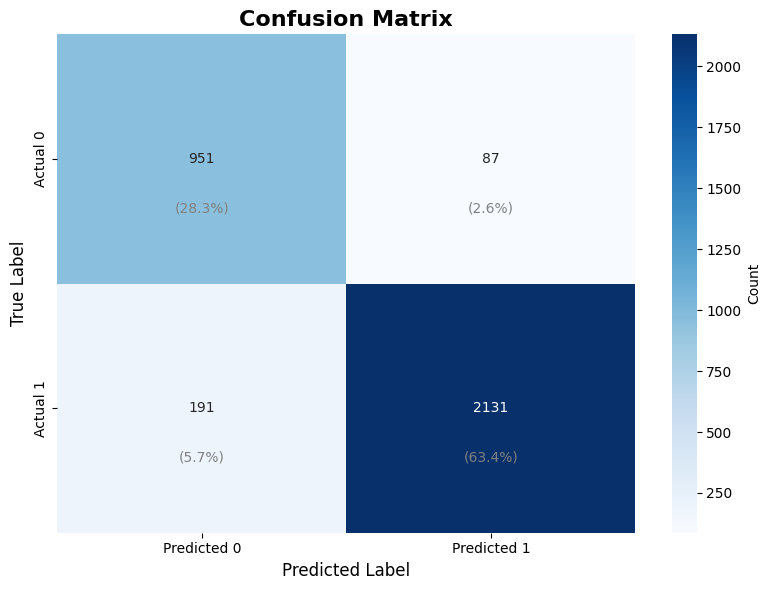

📈 Generating ROC Curve Plot...
✅ ROC curve saved to ./../plots\roc_curve.png


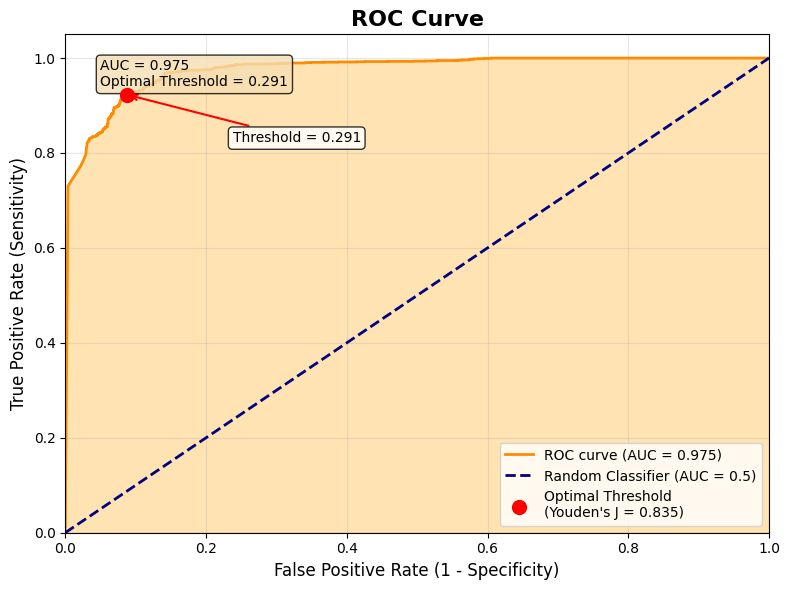


✨ Optimal classification threshold: 0.291
   (Based on Youden's J statistic)


In [8]:

# 1. Split CSV files
data_folder = '../../MainProject/Assignment11/data/kinect_good_preprocessed_not_cut_start_stop'
train_files, val_files, test_files = split_csv_files(data_folder, random_seed=42)

# 2. Create datasets
train_loader, val_loader, test_loader, input_dim = create_lstm_loaders(data_folder=data_folder,
                                                                       train_files=train_files,
                                                                       val_files=val_files,
                                                                       test_files=test_files,
                                                                       sequence_length=10,
                                                                       batch_size=32,
                                                                       target_column="running_video",
                                                                       mirror=True
                                                                       )

# 5. Train model
device = torch.device('cpu')
model, train_losses, val_losses, train_acc, val_acc, training_history = train_binary_classifier(
    train_loader, val_loader, input_dim,
    epochs=50, learning_rate=0.001, device=device
)

plot_training_history(training_history[0], training_history[1], training_history[2], training_history[3], training_history[4])

# 6. Evaluate on test set
metrics = evaluate_binary_classifier(model, test_loader, device)
